# Libraries and Functions

In [1]:
import pynauty as pn
import sys
from pysat.solvers import Glucose3
import itertools
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from grandiso import find_motifs
from tqdm import tqdm

def powerset(iterable):
    "powerset([1,2,3]) --> (1,) (2,) (3,) (1,2) (1,3) (2,3) (1,2,3)"
    s = list(iterable)
    return itertools.chain.from_iterable(itertools.combinations(s, r) for r in range(len(s)+1))

'''Convert NetworkX graph to PyNauty graph'''
def nxToPN(G):
    Gdict = {}
    for v in G.nodes():
        Gdict[v] = list(G.neighbors(v))
    P = pn.Graph(len(G.nodes))
    P.set_adjacency_dict(Gdict)
    return P

'''Check if G-v is (F,H)-good for each v in V(G)'''
def fastFilter( G, filterDict ):
    for x in itertools.combinations(G.nodes(), len(G.nodes())-1):
        Gsub = nx.Graph(G.subgraph(x))
        # exception for disconnected subgraphs
        if ( not nx.is_connected(Gsub) ):
            continue
        Gsub = nx.convert_node_labels_to_integers(Gsub)
        P = nxToPN( Gsub )
        if ( not ( pn.certificate(P) in filterDict.keys() ) ):
            return False
    return True

'''Given graphs F and G, find all sets of edges in G that form F'''
def findFedgesInG( F, G ):
    subGs = find_motifs( F, G )
    allEdges = set([])
    for subG in subGs:
        edges = []
        for e in F.edges():
            u = subG[e[0]]
            v = subG[e[1]]
            edges.append( ( min(u,v), max(u,v) ) )
        edges.sort()
        allEdges.add(tuple(edges))
    return allEdges

'''Given a NetworkX graph G, map its edges to positive integers'''
def makeEdgeMap( G ):
    edges = G.edges()
    eMap = {}
    eMapInv = {}
    idx = 1
    for e in edges:
        eMap[e] = idx
        eMapInv[idx] = e
        idx += 1
    return eMap, eMapInv

'''Construct a CNF formula that is satisfiable iff the input graph is (F,H)-good, and return a Glucose3 solver with said formula '''
def makeFHFormula( G, F, H, eMap ):
    phi = Glucose3()
    
    # avoid red F
    for e in findFedgesInG( F, G ):
        phi.add_clause( [ -eMap[i] for i in e ] ) # at least one must be true, i.e., true = red = +ve

    # avoid blue H
    for e in findFedgesInG( H, G ):
        phi.add_clause( [ eMap[i] for i in e ] )
    
    return phi

'''Given G F and H, return true if G is (F,H)-good'''
def isFHGood( G, F, H ):
    eMap, eMapInv = makeEdgeMap( G ) # map edges to positive integers
    return makeFHFormula( G, F, H, eMap ).solve()

def getFHgoodAssignments( G, F, H ):
    eMap, eMapInv = makeEdgeMap( G ) # map edges to positive integers
    phi = makeFHFormula( G, F, H, eMap )
    colorings = list(phi.enum_models())
    return eMap, eMapInv, colorings

'''Get all (F,H)-good colorings of G as tuple of red edgelist and blue edgelist'''
def getFHgoodColorings( G, F, H ):
    eMAp, eMapInv, colorings = getFHgoodAssignments( G, F, H )
    finalColorings = []
    for c in colorings:
        redEdges = []
        blueEdges = []
        for i in c:
            if ( i > 0 ):
                redEdges.append(eMapInv[i])
            else:
                blueEdges.append(eMapInv[-i])
        finalColorings.append( ( redEdges, blueEdges ) )
    return finalColorings

'''Given colorings, get all vertices adjacent to red edges'''
def getVertsAdjacentToRedEdges( coloring ):
    verts = []
    for e in coloring[0]:
        verts.append( e[0] )
        verts.append( e[1] )
    return verts


'''Given colorings and a set of vertices, get all colorings where said vertices are not adjacent to red edges '''
def getBlueForcedColorings( blueForcedVerts, colorings ):
    finalColorings = []
    
    for coloring in colorings:
        adjToRedVerts = getVertsAdjacentToRedEdges( coloring ) # vertices adjacent to red edges
        
        # ignore colorings not possible when blueforced
        if ( len( set(adjToRedVerts).intersection( set(blueForcedVerts) ) ) == 0 ):
            finalColorings.append(coloring)
    return finalColorings


'''Given graphs G and H, output all edges of G that belong to a copy of H in G'''
def getNonRedundantEdgesH( G, H ):
    nonRedundantEdges = set([])
    for nodeMap in find_motifs( H, G ):
        # make edgeMap
        for e in H.edges():
            corrEdge = ( min( nodeMap[e[0]], nodeMap[e[1]] ), max( nodeMap[e[0]], nodeMap[e[1]] ) )
            nonRedundantEdges.add( corrEdge )
    return nonRedundantEdges

'''Given a graphs G and a list of graphs, output all edges of G that belong to a copy of at least 
one H in HList'''
def getNonRedundantEdgesHList( G, HList ):
    nonRedundantEdges = set(getNonRedundantEdgesH( G, HList[0] ))
    
    for H in HList[1:]:
        nonRedundantEdges = nonRedundantEdges.intersection( getNonRedundantEdgesH( G, H ) )
    
    return nonRedundantEdges

'''Given a graphs G and a list of graphs, output true if the graph has edges that aren't a part of 
any H in HList'''
def hasRedundantEdges( G, HList ):
    mr = len(getNonRedundantEdgesHList( G, HList ))
    m = len(G.edges())
    return mr < m

def printGs(g, blueForcedVerts=[]):
    G = nx.readwrite.graph6.from_graph6_bytes( bytes(g, 'ascii') )
    goodColorings = allColorings[g]
    finalColorings = []
    
    for coloring in goodColorings:
        redVerts = getRedVerts( coloring ) # vertices adjacent to red edges
        # ignore colorings not possible when blueforced
        if ( len( set(redVerts).intersection( set(blueForcedVerts) ) ) > 0 ):
            continue
        
        finalColorings.append( coloring )
    
    printGs_given(G, finalColorings)
    
def printGs_given( G, colorings ):
    for x in colorings:

        pos = nx.kamada_kawai_layout(G)  # positions for all nodes

        # nodes
        options = {"edgecolors": "tab:gray", "node_size": 400, "alpha": 0.9}
        nx.draw_networkx_nodes(G, pos)

        # edges
        nx.draw_networkx_edges(G, pos, width=4.0, alpha=1)
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=x[0],
            width=10,
            alpha=1,
            edge_color="tab:red",
        )
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=x[1],
            width=10,
            alpha=1,
            edge_color="tab:blue",
        )

        nx.draw_networkx_labels(G, pos, font_size=15, font_color="whitesmoke")

        plt.xlim([-1.2, 1.2])
        plt.ylim([-1.2, 1.2])
        plt.axis("off")
        plt.show()
        
# coloring[0] has red edges
# color = 'r' means we are looking at whether this coloring is a red forcer coloring
# red forcer = forces edges to be red
# assumption: coloring does not include red F or blue H
def isForcerColoring( G, F, H, coloring, outVert, color = 'r' ):
    if ( color == 'r' ):
        blueSubgraph = nx.Graph( coloring[1] )
        blueSubgraph.add_edge( outVert, G.number_of_nodes() )
        
        return (find_motifs( H, blueSubgraph, count_only=True, limit=1 ) > 0)
    else:
        redSubgraph = nx.Graph( coloring[0] )
        redSubgraph.add_edge( outVert, G.number_of_nodes() )
        
        return (find_motifs( F,  redSubgraph, count_only=True, limit=1 ) > 0)
    

# forcer vs nonforcer // asym
# red forcer vs blue forcer // symN

# forcer vs nonforcer
def isVarGadget( G, F, H, colorings, a, b, c, check2 = False ):
    
    hasNNF = False
    hasFFN = False
    hasNNN = False
    hasNFN = False
    hasFNN = False
    
    for coloring in colorings:
        currComb = ['N', 'N', 'N']
        if ( isForcerColoring( G, F, H, coloring, a, 'b' ) ):
            currComb[0] = 'F'
            if ( check2 and isForcerColoring( G, F, H, coloring, a, 'r' ) ):
                currComb[0] = 'X'
        if ( isForcerColoring( G, F, H, coloring, b, 'b' ) ):
            currComb[1] = 'F'
            if ( check2 and isForcerColoring( G, F, H, coloring, b, 'r' ) ):
                currComb[1] = 'X'
        if ( isForcerColoring( G, F, H, coloring, c, 'b' ) ):
            currComb[2] = 'F'
            if ( check2 and isForcerColoring( G, F, H, coloring, c, 'r' ) ):
                currComb[2] = 'X'
        currComb = tuple(currComb)
        
        if ( currComb == ('N', 'N', 'F') ):
            hasNNF = True
        if ( currComb == ('F', 'F', 'N') ):
            hasFFN = True
        if ( currComb == ('N', 'N', 'N') ):
            hasNNN = True
        if ( currComb == ('F', 'N', 'N') ):
            hasFNN = True
        if ( currComb == ('N', 'F', 'N') ):
            hasNFN = True
            
    return ( hasNNF and hasFFN and (not hasNNN) and (not hasNFN) and (not hasFNN) )


clauseTemplate = set([
    ('R','R','B'),
    ('R','B','R'),
    ('R','B','B'),
    ('B','R','R'),
    ('B','R','B'),
    ('B','B','R'),
    ('B','B','B')
])


inputMap = {}
inputMap[('B','B','B')] = [ ('R','R','R') ]
inputMap[('B','B','R')] = [ ('R','R','B'), ('R','B','B'), ('B','R','B'), ('B','B','B') ]
inputMap[('B','R','B')] = [ ('R','B','R'), ('R','B','B'), ('B','B','R'), ('B','B','B') ]
inputMap[('B','R','R')] = [ ('R','B','B'), ('B','B','B') ]
inputMap[('R','B','B')] = [ ('B','R','R'), ('B','R','B'), ('B','B','R'), ('B','B','B') ]
inputMap[('R','B','R')] = [ ('B','R','B'), ('B','B','B') ]
inputMap[('R','R','B')] = [ ('B','B','R'), ('B','B','B') ]
inputMap[('R','R','R')] = [ ('B','B','B') ]

def isClauseGadgetVert ( G, colorings, inVerts ):
    possClauseInputCombs = set([])
    
    for coloring in colorings:
        adjToRedVerts = getVertsAdjacentToRedEdges( coloring ) # vertices adjacent to red edges
        
        currentColorComb = ['B','B','B']
        for i in range(3):
            if ( inVerts[i] in adjToRedVerts ):
                currentColorComb[i] = 'R'
        currentColorComb = tuple(currentColorComb)
        
        possClauseInputCombs = possClauseInputCombs.union( inputMap[currentColorComb] )
        
    return ( possClauseInputCombs == clauseTemplate )        

# Setup

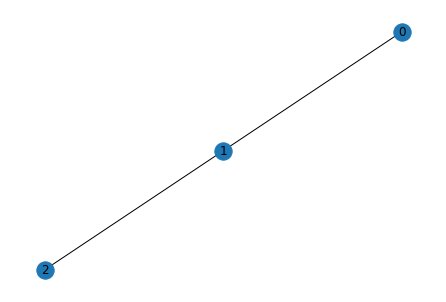

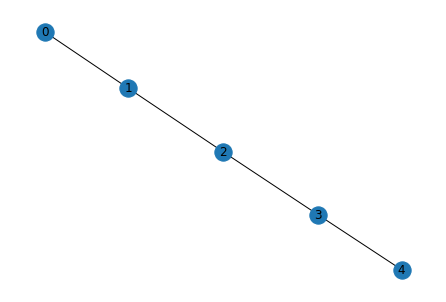

<Figure size 432x288 with 0 Axes>

In [2]:
name = 'P3_P5'
F = nx.Graph( [ (0,1),  (1,2) ] )
H = nx.Graph( [ (0,1), (1,2), (2,3), (3,4)] )
nautypath = '../nauty2_8_8/'
for J in [F, H]:
    nx.draw(J, with_labels="true")
    plt.figure()

# Generating Iteratively

### Generate all good graphs on three vertices

In [3]:
%%bash -s "$name" "$nautypath"
cd $2
./geng 3 -c > $1-3-final.g6

>A ./geng -cd1D2 n=3 e=2-3
>Z 2 graphs generated in 0.00 sec


### Using good graphs on n vertices, get good graphs on n+1 vertices

In [25]:
n = 3
n_plus_one = n + 1
# get all extension

In [26]:
%%bash -s "$n" "$n_plus_one" "$name" "$nautypath"
cd $4
cat $3-$1-final.g6 | ./addptg -j1:100 | ./shortg | ./pickg -C > $3-$2-int.g6

>A addptg -j1:100
>A shortg
>Z  2 graphs read from stdin, 14 written to stdout; 0.00 sec.
>A ./pickg -C
>Z 14 graphs read from stdin
>Z 6 graphs written to stdout
>Z 6 graphs read from stdin; 6 written to stdout; 0.00 sec


In [27]:
# make filter dict
f = open(nautypath+name+'-'+str(n)+'-final.g6', 'r')
g6gs = [i[:-1] for i in f.readlines()]
filterDict = {}
for g in g6gs:
    G = nx.readwrite.graph6.from_graph6_bytes( bytes(g, 'ascii') )
    P = nxToPN(G)
    filterDict[pn.certificate(P)] = 1

f = open(nautypath+name+'-'+str(n_plus_one)+'-int.g6', 'r')
g6gs = [i[:-1] for i in f.readlines()]

finalg6gs = []

for g in g6gs:
    G = nx.readwrite.graph6.from_graph6_bytes( bytes(g, 'ascii') )
    if ( fastFilter( G, filterDict ) ):
        if ( isFHGood( G, F, H ) ):
            finalg6gs.append( g + "\n" )


f2 = open(nautypath+name+'-'+str(n_plus_one)+'-final.g6', "w")
f2.writelines(finalg6gs)
f2.close()
print(len(finalg6gs))

6


### Collect all good graphs

In [28]:
%%bash -s "$name" "$nautypath"
cd $2
cat $1-*-final.g6 > $1-cands.g6

# Gadget Hunting

In [ ]:
f = open(nautypath+name+'-cands.g6', 'r')
g6gs = [i[:-1] for i in f.readlines()]

### Get graphs without redundant edges

In [ ]:
finalg6gs = []
for g in tqdm(g6gs):
    G = nx.readwrite.graph6.from_graph6_bytes( bytes(g, 'ascii') )
    if ( not hasRedundantEdges( G, [F, H] ) ):
        finalg6gs.append( g )
g6gs = finalg6gs

### Get all colorings for each graph

In [ ]:
allColorings = {}
for g in tqdm(g6gs):
    G = nx.readwrite.graph6.from_graph6_bytes( bytes(g, 'ascii') )
    allColorings[g] = getFHgoodColorings( G, F, H )

### Find enforcer

In [ ]:
foundEN = []

for g in tqdm(g6gs):
    G = nx.readwrite.graph6.from_graph6_bytes( bytes(g, 'ascii') )
    colorings = allColorings[g]
    for v in G.nodes():
        redInAll = True
        for c in colorings:
            redVerts1 = [ a for a,b in c[0] ]
            redVerts2 = [ b for a,b in c[0] ]
            
            if ( v not in (redVerts1+redVerts2) ):
                redInAll = False
                break
        if ( redInAll ):
            foundEN.append( (G, v) )
            
print( len(foundEN) )

### Find variable gadgets

In [ ]:
num_blueforced = 0 # number of vertices that have enforcers appended to them

foundVar = []

for g in tqdm(g6gs):
    G = nx.readwrite.graph6.from_graph6_bytes( bytes(g, 'ascii') )

    colorings = allColorings[g]
    for outVerts in itertools.combinations( G.nodes(), 3 ):

        allOtherVerts = list( G.nodes() )
        allOtherVerts.remove(outVerts[0])
        allOtherVerts.remove(outVerts[1])
        allOtherVerts.remove(outVerts[2])

        for c in outVerts:
            rem = list(outVerts).copy()
            rem.remove(c)
            a = rem[0]
            b = rem[1]

            for blueForcedVerts in itertools.combinations( allOtherVerts, num_blueforced ):
                newCols = getBlueForcedColorings( blueForcedVerts, colorings )

                if ( isVarGadget( G, F, H, newCols, a, b, c, True ) ):
                    val = (G, newCols, a, b, c, blueForcedVerts)
                    foundVar.append(val)

print( len(foundVar) )

### Find clause gadgets

In [ ]:
num_blueforced = 0 # number of vertices that have enforcers appended to them

foundCL = []

for g in tqdm(g6gs):
    G = nx.readwrite.graph6.from_graph6_bytes( bytes(g, 'ascii') )
    
    colorings = allColorings[g]
    for outVerts in itertools.combinations( G.nodes(), 3 ):

        allOtherVerts = list( G.nodes() )
        allOtherVerts.remove(outVerts[0])
        allOtherVerts.remove(outVerts[1])
        allOtherVerts.remove(outVerts[2])


        for blueForcedVerts in itertools.combinations( allOtherVerts, num_blueforced ):
            newCols = getBlueForcedColorings( blueForcedVerts, colorings )

            if ( isClauseGadgetVert( G, newCols, outVerts ) ):
                val = (G, newCols, outVerts[0], outVerts[1], outVerts[2], blueForcedVerts)
                foundCL.append(val)


print( len(foundCL) )

### View enforcer gadgets

In [ ]:
my_it = iter( foundEN )

In [ ]:
# rerun cell to view next graph
curr = next(my_it)
G, v = curr
print(v)
nx.draw(G, with_labels=True)
plt.figure()

### View variable gadgets

In [ ]:
my_it = iter( foundVar )

In [ ]:
# rerun cell to view next graph
curr = next(my_it)
G, colorings, a, b, c, bfv = curr
print(a, b, c, bfv)
nx.draw(G, with_labels=True)
plt.figure()
printGs_given( G, colorings )

### View clause gadgets

In [ ]:
my_it = iter( foundCL )

In [ ]:
# rerun cell to view next graph
curr = next(my_it)
G, colorings, a, b, c, bfv = curr
print(a, b, c, bfv)
nx.draw(G, with_labels=True)
plt.figure()
printGs_given( G, colorings )